In [1]:
DATASET_DIR = "/kaggle/input/datasets/quandang/nomnaocr/Patches"
ALL_TRANSCRIPTS_PATH = "/kaggle/input/datasets/quandang/nomnaocr/Patches/All.txt"
VALID_TRANSCRIPTS_PATH = "/kaggle/input/datasets/quandang/nomnaocr/Patches/Validate.txt"
APPROACH_NAME = 'CRNNxCTC'

In [2]:
import os
import urllib.request

# Download the NomNaTong font required to render Hán-Nôm characters
FONT_PATH = "NomNaTong-Regular.ttf"
FONT_URL = "https://github.com/nomfoundation/font/releases/download/v5.17/NomNaTong-Regular.ttf"

if not os.path.exists(FONT_PATH):
    print("Downloading NomNaTong-Regular.ttf font...")
    urllib.request.urlretrieve(FONT_URL, FONT_PATH)
    print("Font downloaded successfully!")
else:
    print("Font file already present.")

Font downloaded successfully!


In [3]:
import os
import re
import random
import csv
import numpy as np
import pandas as pd
from string import printable
from collections import Counter, defaultdict
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms.functional as TF
from PIL import Image

import nltk


class DataImporter:
    def __init__(self, dataset_dir, labels_path, min_length=4):
        self.img_paths, self.labels = [], []
        with open(labels_path, 'r', encoding='utf-8') as file:
            for line in file:
                img_name, text = line.rstrip('\n').split('\t')
                img_path = os.path.join(dataset_dir, img_name)
                text = text.strip().lower()

                if os.path.getsize(img_path) and len(text) >= min_length and self.is_clean_text(text):
                    self.img_paths.append(img_path)
                    self.labels.append(text)
        
        assert len(self.img_paths) == len(self.labels), 'img_paths and labels must have same size'
        self.img_paths = np.array(self.img_paths)
        self.labels = np.array(self.labels)
        self.vocabs = dict(Counter(''.join(self.labels)).most_common())
        self.size = len(self.labels)

    def remove_rare_chars(self, threshold=1):
        if threshold < 2: return self
        rare_chars, idxs_to_remove = [], []

        for char, freq in reversed(self.vocabs.items()):
            if freq < threshold: rare_chars.append(char)
            else: break

        for idx, label in enumerate(self.labels):
            if any((char in label) for char in rare_chars):
                idxs_to_remove.append(idx)

        idxs_to_remove = np.array(idxs_to_remove)
        self.img_paths = np.delete(self.img_paths, idxs_to_remove)
        self.labels = np.delete(self.labels, idxs_to_remove)

        assert len(self.img_paths) == len(self.labels), 'img_paths and labels must have same size'
        self.vocabs = dict(Counter(''.join(self.labels)).most_common())
        self.size = len(self.labels)

        smallest_freq = threshold + 1
        if len(self.vocabs) >= 1: smallest_freq = list(self.vocabs.values())[-1]
        return self.remove_rare_chars(threshold) if smallest_freq < threshold else self

    def is_clean_text(self, text):
        not_nom_chars = r'\sáàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệóòỏõọôốồổỗộơớờởỡợíìỉĩịúùủũụưứừửữựýỳỷỹỵđ'
        pattern = re.compile(f'[{not_nom_chars}{re.escape(printable)}]')
        return not bool(re.search(pattern, text.lower()))

    def __str__(self):
        return (
            f'Samples count (not include Latin letters, numbers, punctuations):'
            f'\n- Number of images found: {len(self.img_paths)}'
            f'\n- Number of labels found: {len(self.labels)}'
            f'\n- Number of unique characters: {len(self.vocabs)}'
            f'\n- Characters present: {self.vocabs}'
        )


class PyTorchDataset(Dataset):
    def __init__(self, data_handler, idxs, img_align_top=True):
        self.data_handler = data_handler
        self.idxs = idxs
        self.img_align_top = img_align_top

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, idx):
        real_idx = self.idxs[idx]
        img_path = self.data_handler.img_paths[real_idx]
        label = self.data_handler.labels[real_idx]

        image = self.data_handler.process_image(img_path, self.img_align_top)
        label_tensor = self.data_handler.process_label(label)
        return image, label_tensor


class DataHandler:
    def __init__(self, dataset: DataImporter, img_size: tuple, padding_char, start_char='', end_char=''):
        self.img_paths = dataset.img_paths
        self.labels = dataset.labels
        self.vocabs = dataset.vocabs

        self.img_size = img_size
        self.padding_char = padding_char
        self.start_char = start_char
        self.end_char = end_char

        # Building vocabulary and token mappings (0 reserved for [PAD]/blank)
        vocabulary = list(self.vocabs)
        if start_char != '' and end_char != '': vocabulary += [start_char, end_char]

        self.char2id = {self.padding_char: 0, '[UNK]': 1}
        for char in vocabulary:
            if char not in self.char2id:
                self.char2id[char] = len(self.char2id)

        self.id2char = {v: k for k, v in self.char2id.items()}

        self.max_length = max([len(label) for label in self.labels])
        self.start_token, self.end_token = None, None
        self.start_concat, self.end_concat = [], []
        mask_idxs = [0, 1]

        if self.start_char != '' and self.end_char != '':
            self.start_token = self.char2id[start_char]
            self.end_token = self.char2id[end_char]
            self.start_concat = [self.start_token]
            self.end_concat = [self.end_token]
            self.max_length += 2
            mask_idxs.append(self.start_token)

        token_mask = np.zeros([len(self.char2id)], dtype=bool)
        token_mask[np.array(mask_idxs)] = True
        self.token_mask = token_mask


    def decode_predictions(self, preds):
        """
        Greedy CTC decoding.
    
        preds: model output of shape (N, T, C),
               already log-softmaxed.
        """
        return self.tokens2texts(
            preds.argmax(dim=-1),
            use_ctc_decode=True
        )

    def vocab_size(self):
        return len(self.char2id)

    def distortion_free_resize(self, image, align_top=True):
        # Image is PIL image
        target_h, target_w = self.img_size
        w, h = image.size

        # Calculate aspect ratio preserving size
        aspect_ratio = w / h
        if target_w / target_h > aspect_ratio:
            new_h = target_h
            new_w = int(aspect_ratio * target_h)
        else:
            new_w = target_w
            new_h = int(target_w / aspect_ratio)

        resized = image.resize((new_w, new_h), Image.Resampling.BILINEAR)

        pad_height = target_h - new_h
        pad_width = target_w - new_w

        if pad_height % 2 != 0:
            pad_height_top, pad_height_bottom = pad_height // 2 + 1, pad_height // 2
        else:
            pad_height_top = pad_height_bottom = pad_height // 2

        if pad_width % 2 != 0:
            pad_width_left, pad_width_right = pad_width // 2 + 1, pad_width // 2
        else:
            pad_width_left = pad_width_right = pad_width // 2

        padding = (
            pad_width_left,
            0 if align_top else pad_height_top,
            pad_width_right,
            pad_height_top + pad_height_bottom if align_top else pad_height_bottom
        )
        return TF.pad(resized, padding, fill=255)

    def process_image(self, img_path, img_align_top=True):
        image = Image.open(img_path).convert('RGB')
        image = self.distortion_free_resize(image, img_align_top)
        tensor_img = TF.to_tensor(image)  # Shape: (3, H, W), normalized to [0, 1]
        return tensor_img

    def process_label(self, label):
        tokens = [self.char2id.get(char, self.char2id['[UNK]']) for char in list(label)]
        tokens = self.start_concat + tokens + self.end_concat
        label_length = len(tokens)
        pad_len = self.max_length - label_length
        if pad_len > 0:
            tokens = tokens + [0] * pad_len
        return torch.tensor(tokens, dtype=torch.long)

    def prepare_pytorch_dataset(self, idxs, batch_size, drop_remainder=False, img_align_top=True, shuffle=False):
        dataset = PyTorchDataset(self, idxs, img_align_top=img_align_top)
        dataloader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=shuffle,
            drop_last=drop_remainder,
            num_workers=4,
            persistent_workers=True,
            pin_memory=True,
        )
        return dataloader

    def tokens2texts(self, batch_tokens, use_ctc_decode=False):
        batch_texts = []
        if torch.is_tensor(batch_tokens):
            batch_tokens = batch_tokens.detach().cpu().numpy()

        if use_ctc_decode:
            # Simple CTC greedy decode
            decoded_batch = []
            for seq in batch_tokens:
                if len(seq.shape) > 1:  # Probability or logit inputs
                    seq = np.argmax(seq, axis=-1)

                prev_token = None
                decoded_seq = []
                for t in seq:
                    if t != prev_token and t != 0:  # 0 is CTC blank / [PAD]
                        decoded_seq.append(t)
                    prev_token = t
                decoded_batch.append(decoded_seq)
            batch_tokens = decoded_batch

        for tokens in batch_tokens:
            chars = []
            for t in tokens:
                if t in (0, -1): continue
                char = self.id2char.get(int(t), '[UNK]')
                chars.append(char)
            text = ''.join(chars)
            text = text.replace(self.start_char, '').replace(self.end_char, '')
            batch_texts.append(text)
        return batch_texts


dataset = DataImporter(DATASET_DIR, ALL_TRANSCRIPTS_PATH, min_length=1)
# print(dataset)

In [4]:
HEIGHT, WIDTH = 432, 48
PADDING_CHAR = '[PAD]'
BATCH_SIZE = 32

data_handler = DataHandler(dataset, img_size=(HEIGHT, WIDTH), padding_char=PADDING_CHAR)
NUM_VALIDATE = DataImporter(DATASET_DIR, VALID_TRANSCRIPTS_PATH, min_length=1).size
VOCAB_SIZE = data_handler.vocab_size()

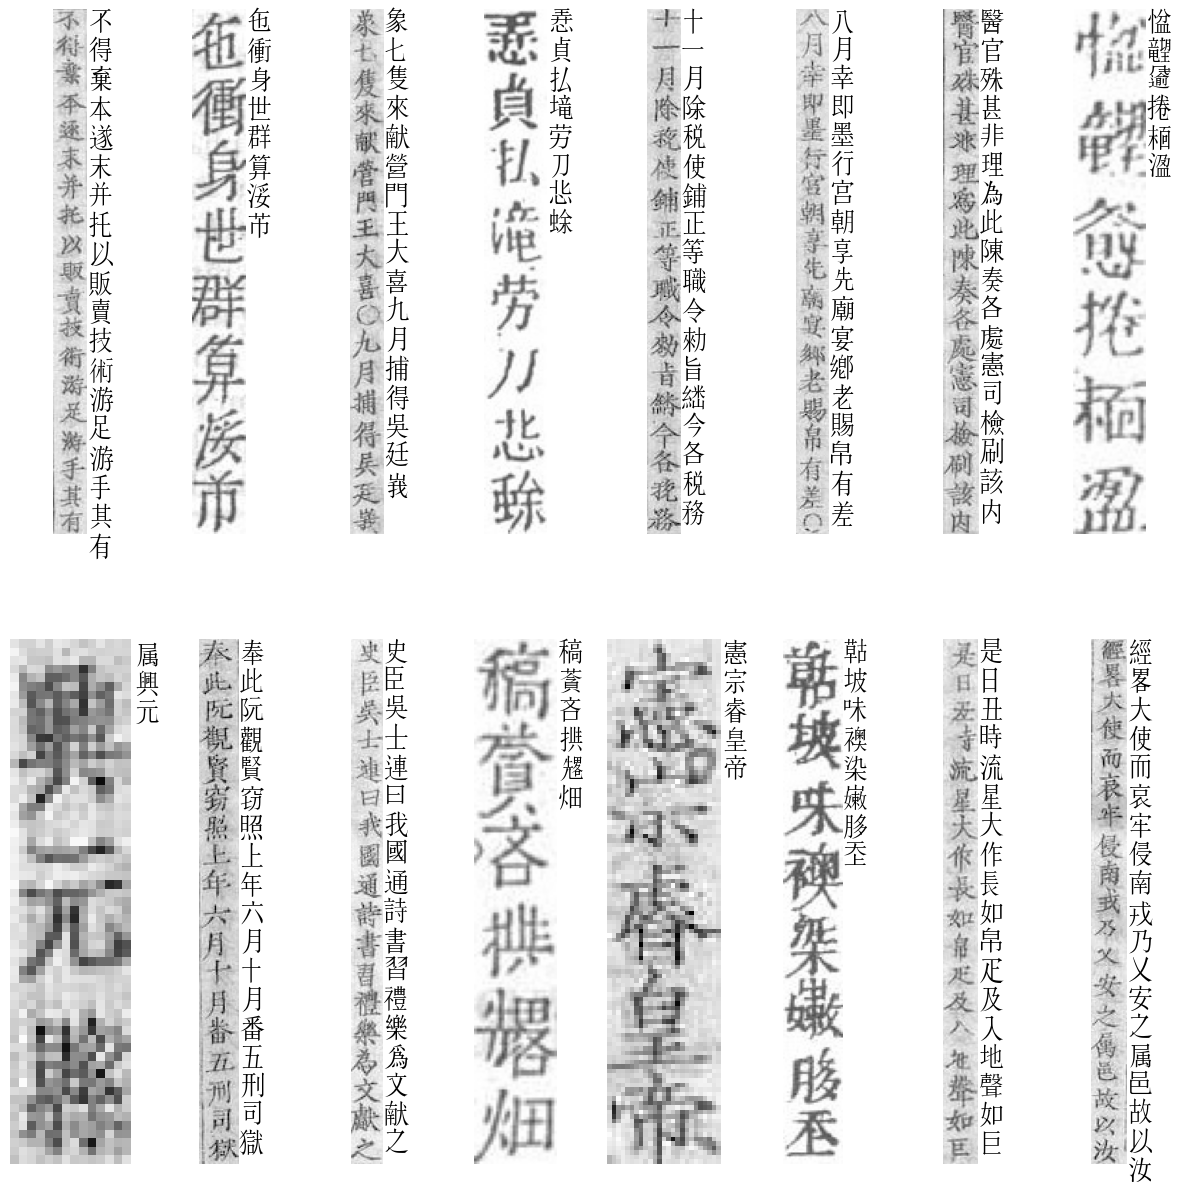

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.font_manager import FontProperties


def draw_predicted_text(label, pred_label, fontdict, width, height):
    label = label.replace('[UNK]', '?')
    label_length, pred_length = len(label), len(pred_label)

    if pred_label == label:
        fontdict['color'] = 'green'
        plt.text(width, 0, '\n'.join(pred_label), fontdict=fontdict)
        return

    pred_start, start, end = 0, 0, 0
    while start <= end < label_length:
        text_y = end * height / label_length
        actual_char = '[UNK]' if label[end] == '?' else label[end]

        if label[start:end + 1] in pred_label[pred_start:pred_length]:
            fontdict['color'] = 'dodgerblue'
            plt.text(width, text_y, actual_char, fontdict=fontdict)
        else:
            if end < pred_length and end + 1 < label_length and pred_label[end] == label[end + 1]:
                fontdict['color'] = 'gray'
                plt.text(width, text_y, actual_char, fontdict=fontdict)
            elif end < pred_length:
                fontdict['color'] = 'red'
                plt.text(width, text_y, pred_label[end], fontdict=fontdict)
                fontdict['color'] = 'black'
                plt.text(width * 2, text_y, actual_char, fontdict=fontdict)
            else:
                fontdict['color'] = 'gray'
                plt.text(width, text_y, actual_char, fontdict=fontdict)
              
            pred_start = end
            start = end + 1
        end += 1


def visualize_images_labels(
    img_paths,
    labels,
    pred_labels = None,
    figsize = (15, 8),
    subplot_size = (2, 8),
    legend_loc = None,
    annotate_loc = None,
    font_path = None
):
    nrows, ncols = subplot_size
    num_of_labels = len(labels)
    assert len(img_paths) == num_of_labels, 'img_paths and labels must have same number of items'
    assert nrows * ncols <= num_of_labels, f'nrows * ncols must be <= {num_of_labels}'
    fontdict = {
        'fontproperties': FontProperties(fname=font_path),
        'fontsize': 18,
        'color': 'black',
        'verticalalignment': 'top',
        'horizontalalignment': 'left'
    }

    plt.figure(figsize=figsize)
    for i in range(min(nrows * ncols, num_of_labels)):
        plt.subplot(nrows, ncols, i + 1)
        image, label = plt.imread(img_paths[i]), labels[i]
        height, width, channel = image.shape
        plt.imshow(image)

        fontdict['color'] = 'black'
        if pred_labels: draw_predicted_text(label, pred_labels[i], fontdict, width, height)
        else: plt.text(width, 0, '\n'.join(label), fontdict=fontdict)
        plt.axis('off')

    if legend_loc and annotate_loc and pred_labels:
        plt.subplots_adjust(left=0, right=0.75)
        plt.legend(handles=[
            Patch(color='green', label='Full match'),
            Patch(color='dodgerblue', label='Character match'),
            Patch(color='red', label='Wrong prediction'),
            Patch(color='black', label='Actual character'),
            Patch(color='gray', label='Missing position'),
        ], loc=legend_loc)

        annotate_text = [f'{idx + 1:02d}. {text}' for idx, text in enumerate(pred_labels)]
        plt.annotate(
            f'Model predictions:\n{chr(10).join(annotate_text)}',
            fontproperties = FontProperties(fname=font_path),
            xycoords = 'axes fraction',
            fontsize = 14,
            xy = annotate_loc,
        )


def plot_training_results(history, save_name, figsize=(16, 14), subplot_size=(2, 2)):
    nrows, ncols = subplot_size
    if 'lr' in history.keys(): del history['lr']
    assert nrows * ncols <= len(history), f'nrows * ncols must be <= {len(history)}'
    fig = plt.figure(figsize=figsize)

    for idx, name in enumerate(history):
        if 'val' in name: continue
        plt.subplot(nrows, ncols, idx + 1)
        plt.plot(history[name], linestyle='solid', marker='o', color='crimson', label='Train')
        plt.plot(history[f'val_{name}'], linestyle='solid', marker='o', color='dodgerblue', label='Validation')
        plt.xlabel('Epochs', fontsize=14)
        plt.ylabel(name, fontsize=14)

        title = name.replace('acc', 'accuracy')\
                    .replace('seq_', 'sequence_')\
                    .replace('char_', 'character_')\
                    .replace('lev_', 'levenshtein_')\
                    .replace('edit_', 'levenshtein_')\
                    .replace('_', ' ').capitalize()
        plt.title(title, fontsize=18)
        plt.legend(loc='best')

    fig.savefig(save_name, bbox_inches='tight')
    plt.show()


visualize_images_labels(
    dataset.img_paths,
    dataset.labels,
    figsize = (15, 15),
    subplot_size = (2, 8),
    font_path = FONT_PATH
)

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        num_conv=2,
        pool_size=None,
        dropout_p=0.1,
        alpha=0
    ):
        super().__init__()

        layers = []

        for i in range(num_conv):
            layers.append(
                nn.Conv2d(
                    in_channels if i == 0 else out_channels,
                    out_channels,
                    kernel_size=3,
                    padding=1,
                    bias=False
                )
            )
            layers.append(nn.BatchNorm2d(out_channels))

            if alpha > 0:
                layers.append(
                    nn.LeakyReLU(
                        negative_slope=alpha,
                        inplace=True
                    )
                )
            else:
                layers.append(
                    nn.ReLU(inplace=True)
                )

        if pool_size is not None:
            layers.append(
                nn.MaxPool2d(
                    kernel_size=pool_size,
                    stride=pool_size
                )
            )

        if dropout_p > 0:
            layers.append(
                nn.Dropout2d(dropout_p)
            )

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class CustomCNN(nn.Module):
    def __init__(
        self,
        config,
        in_channels=3,
        alpha=0,
        dropout_p=0.1
    ):
        super().__init__()

        layers = []
        curr_channels = in_channels

        for block_name, block_config in config.items():

            filters = block_config['filters']
            num_conv = block_config['num_conv']
            pool_size = block_config.get('pool_size')

            layers.append(
                ConvBlock(
                    in_channels=curr_channels,
                    out_channels=filters,
                    num_conv=num_conv,
                    pool_size=pool_size,
                    dropout_p=dropout_p,
                    alpha=alpha
                )
            )

            curr_channels = filters

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class ResidualBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        stride=(1, 1),
        dropout_p=0.05
    ):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        self.dropout = nn.Dropout2d(dropout_p)

        # Projection shortcut when dimensions change
        if (
            in_channels != out_channels
            or stride != (1, 1)
        ):
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):

        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = self.dropout(out)

        out = out + identity
        out = self.relu(out)

        return out


class ResidualCNN(nn.Module):
    def __init__(self, dropout_p=0.05):
        super().__init__()

        # --------------------------------------------------
        # Stem
        # --------------------------------------------------

        self.stem = nn.Sequential(
            nn.Conv2d(
                3,
                64,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        # --------------------------------------------------
        # Stage 1
        #
        # 432 × 48
        # -> 216 × 24
        # --------------------------------------------------

        self.stage1 = nn.Sequential(

            ResidualBlock(
                64,
                64,
                stride=(1, 1),
                dropout_p=dropout_p
            ),

            ResidualBlock(
                64,
                64,
                stride=(1, 1),
                dropout_p=dropout_p
            ),

            nn.MaxPool2d(
                kernel_size=(2, 2),
                stride=(2, 2)
            )
        )

        # --------------------------------------------------
        # Stage 2
        #
        # 216 × 24
        # -> 108 × 12
        # --------------------------------------------------

        self.stage2 = nn.Sequential(

            ResidualBlock(
                64,
                128,
                stride=(1, 1),
                dropout_p=dropout_p
            ),

            ResidualBlock(
                128,
                128,
                stride=(1, 1),
                dropout_p=dropout_p
            ),

            nn.MaxPool2d(
                kernel_size=(2, 2),
                stride=(2, 2)
            )
        )

        # --------------------------------------------------
        # Stage 3
        #
        # 108 × 12
        # -> 54 × 12
        #
        # ONLY reduce height here.
        # --------------------------------------------------

        self.stage3 = nn.Sequential(

            ResidualBlock(
                128,
                256,
                stride=(1, 1),
                dropout_p=dropout_p
            ),

            ResidualBlock(
                256,
                256,
                stride=(1, 1),
                dropout_p=dropout_p
            ),

            nn.MaxPool2d(
                kernel_size=(2, 1),
                stride=(2, 1)
            )
        )

        # --------------------------------------------------
        # Stage 4
        #
        # 54 × 12
        # -> 54 × 12
        # --------------------------------------------------

        self.stage4 = nn.Sequential(

            ResidualBlock(
                256,
                512,
                stride=(1, 1),
                dropout_p=dropout_p
            ),

            ResidualBlock(
                512,
                512,
                stride=(1, 1),
                dropout_p=dropout_p
            )
        )

    def forward(self, x):

        x = self.stem(x)

        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)

        return x


class CRNN(nn.Module):

    def __init__(
        self,
        vocab_size,
        dropout_p=0.2
    ):
        super().__init__()

        # ==============================================
        # Residual CNN
        # ==============================================

        self.cnn = ResidualCNN(
            dropout_p=0.05
        )

        # ==============================================
        # Collapse horizontal dimension
        #
        # 512 × 54 × 12
        #
        # -> 512 × 54 × 1
        #
        # This is LEARNED, unlike AdaptiveAvgPool.
        # ==============================================

        self.width_projection = nn.Sequential(

            nn.Conv2d(
                512,
                512,
                kernel_size=(1, 12),
                stride=(1, 1),
                padding=0,
                bias=False
            ),

            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

        # ==============================================
        # Sequence projection
        #
        # No giant linear layer is required.
        #
        # After squeeze:
        #
        # (N, 512, 54)
        #
        # -> (N, 54, 512)
        # ==============================================

        self.sequence_dropout = nn.Dropout(
            dropout_p
        )

        # ==============================================
        # BiGRU 1
        # ==============================================

        self.bigru1 = nn.GRU(
            input_size=512,
            hidden_size=256,
            num_layers=1,
            bidirectional=True,
            batch_first=True
        )

        # ==============================================
        # BiGRU 2
        # ==============================================

        self.bigru2 = nn.GRU(
            input_size=512,
            hidden_size=256,
            num_layers=1,
            bidirectional=True,
            batch_first=True
        )

        # ==============================================
        # CTC classifier
        #
        # vocab_size already includes blank (0)
        # ==============================================

        self.fc = nn.Linear(
            512,
            vocab_size
        )

    def forward(self, x):

        # ==============================================
        # CNN
        # ==============================================

        x = self.cnn(x)

        # Expected:
        #
        # N × 512 × 54 × 12

        # ==============================================
        # Width projection
        # ==============================================

        x = self.width_projection(x)

        # N × 512 × 54 × 1

        x = x.squeeze(-1)

        # N × 512 × 54

        x = x.permute(
            0,
            2,
            1
        ).contiguous()

        # N × 54 × 512

        # ==============================================
        # BiGRU 1
        # ==============================================

        x, _ = self.bigru1(x)

        x = self.sequence_dropout(x)

        # ==============================================
        # BiGRU 2
        # ==============================================

        x, _ = self.bigru2(x)

        x = self.sequence_dropout(x)

        # ==============================================
        # CTC
        # ==============================================

        x = self.fc(x)

        return F.log_softmax(
            x,
            dim=-1
        )

def build_crnn(vocab_size, dropout_p=0.2):
    return CRNN(vocab_size, dropout_p=dropout_p)

# Instantiate Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = build_crnn(VOCAB_SIZE, dropout_p=0.2).to(device)
print(model)

CRNN(
  (cnn): ResidualCNN(
    (stem): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (stage1): Sequential(
      (0): ResidualBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (dropout): Dropout2d(p=0.05, inplace=False)
        (shortcut): Identity()
      )
      (1): ResidualBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1

In [7]:
train_idxs = list(range(dataset.size - NUM_VALIDATE))
valid_idxs = list(range(train_idxs[-1] + 1, dataset.size))
print('Number of training samples:', len(train_idxs))
print('Number of validate samples:', len(valid_idxs))

random.seed(2022)
random.shuffle(train_idxs)

train_loader = data_handler.prepare_pytorch_dataset(train_idxs, BATCH_SIZE, shuffle=True)
valid_loader = data_handler.prepare_pytorch_dataset(valid_idxs, BATCH_SIZE, shuffle=False)

Number of training samples: 30259
Number of validate samples: 7577


In [8]:
class SequenceAccuracy:
    def __init__(self, data_handler):
        self.data_handler = data_handler
        self.reset()

    def reset(self):
        self.correct = 0
        self.total = 0

    def update(self, y_true_texts, y_pred_texts):
        for true, pred in zip(y_true_texts, y_pred_texts):
            if true == pred:
                self.correct += 1
            self.total += 1

    def compute(self):
        return self.correct / self.total if self.total > 0 else 0.0


# FIX
class CharacterAccuracy:
    def __init__(self, data_handler):
        self.reset()

    def reset(self):
        self.total_edit_distance = 0
        self.total_chars = 0

    def update(self, y_true_texts, y_pred_texts):
        for true, pred in zip(y_true_texts, y_pred_texts):
            dist = nltk.edit_distance(pred, true)
            self.total_edit_distance += dist
            self.total_chars += max(len(true), 1)

    def compute(self):
        # Character Accuracy = 1 - CER
        cer = self.total_edit_distance / self.total_chars if self.total_chars > 0 else 0.0
        return max(0.0, 1.0 - cer)


class LevenshteinDistance:
    def __init__(self, data_handler, normalize=True):
        self.data_handler = data_handler
        self.normalize = normalize
        self.reset()

    def reset(self):
        self.total_dist = 0
        self.total_count = 0

    def update(self, y_true_texts, y_pred_texts):
        for true, pred in zip(y_true_texts, y_pred_texts):
            dist = nltk.edit_distance(pred, true)
            if self.normalize:
                dist = dist / max(len(true), 1)
            self.total_dist += dist
            self.total_count += 1

    def compute(self):
        return self.total_dist / self.total_count if self.total_count > 0 else 0.0

In [9]:
import copy
class EarlyStopping:
    def __init__(
        self,
        patience=8,
        min_delta=1e-4,
        restore_best_weights=True
    ):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights

        self.best_metric = float('inf')
        self.best_epoch = 0
        self.counter = 0
        self.best_weights = None

    def __call__(self, metric, model, epoch):

        if metric < self.best_metric - self.min_delta:

            self.best_metric = metric
            self.best_epoch = epoch
            self.counter = 0

            if self.restore_best_weights:
                self.best_weights = copy.deepcopy(
                    model.state_dict()
                )

        else:
            self.counter += 1

            if self.counter >= self.patience:

                if self.restore_best_weights:
                    model.load_state_dict(self.best_weights)

                return True

        return False

In [10]:
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

LEARNING_RATE = 1e-3
MAX_LR = 1e-3
EPOCHS = 100

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
ctc_loss_fn = nn.CTCLoss(blank=0, zero_infinity=True)
early_stopping = EarlyStopping(
    patience=5,
    min_delta=1e-3,
    restore_best_weights=True
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=MAX_LR,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=0.1,  # Warm up for first 10% of training
    anneal_strategy='cos'
)

# Training loop
history = defaultdict(list)

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    seq_acc_metric = SequenceAccuracy(data_handler)
    char_acc_metric = CharacterAccuracy(data_handler)
    lev_metric = LevenshteinDistance(data_handler, normalize=True)

    train_pbar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS} [Train]",
        leave=False
    )

    for images, labels in train_pbar:
        images = images.to(device)
        optimizer.zero_grad()

        preds = model(images)  # (N, T, C)

        # Prepare inputs for PyTorch CTCLoss (requires T, N, C)
        log_probs = preds.permute(1, 0, 2)

        input_lengths = torch.full(
            size=(images.size(0),),
            fill_value=preds.size(1),
            dtype=torch.long
        )

        # Compute non-padded target lengths
        targets_1d = torch.cat([label[label != 0] for label in labels])
        target_lengths = torch.tensor(
            [len(label[label != 0]) for label in labels], 
            dtype=torch.long,
            device=images.device
        )

        loss = ctc_loss_fn(
            log_probs,
            targets_1d,        # Use 1D unpadded concatenated tensor
            input_lengths,
            target_lengths
        )

        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item() * images.size(0)

        # Decoding for metrics
        pred_texts = data_handler.tokens2texts(
            preds.argmax(dim=-1),
            use_ctc_decode=True
        )
        true_texts = data_handler.tokens2texts(
            labels,
            use_ctc_decode=False
        )

        seq_acc_metric.update(true_texts, pred_texts)
        char_acc_metric.update(true_texts, pred_texts)
        lev_metric.update(true_texts, pred_texts)

        train_pbar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss /= len(train_loader.dataset)

    history['loss'].append(train_loss)
    history['seq_acc'].append(seq_acc_metric.compute())
    history['char_acc'].append(char_acc_metric.compute())
    history['levenshtein_distance'].append(lev_metric.compute())

    # Validation phase
    model.eval()
    val_loss = 0.0

    # Greedy validation metrics
    val_seq_acc = SequenceAccuracy(data_handler)
    val_char_acc = CharacterAccuracy(data_handler)
    val_lev = LevenshteinDistance(
        data_handler,
        normalize=True
    )

    val_pbar = tqdm(
        valid_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS} [Valid]",
        leave=False
    )

    with torch.no_grad():
        for images, labels in val_pbar:
            images = images.to(device)

            preds = model(images)

            log_probs = preds.permute(1, 0, 2)

            input_lengths = torch.full(
                size=(images.size(0),),
                fill_value=preds.size(1),
                dtype=torch.long
            )

            targets_1d = torch.cat([label[label != 0] for label in labels])
            target_lengths = torch.tensor(
                [len(label[label != 0]) for label in labels], 
                dtype=torch.long,
                device=images.device
            )

            loss = ctc_loss_fn(
                log_probs,
                targets_1d,
                input_lengths,
                target_lengths
            )

            val_loss += loss.item() * images.size(0)

            # Ground truth
            true_texts = data_handler.tokens2texts(
                labels,
                use_ctc_decode=False
            )
            
            pred_texts = data_handler.tokens2texts(
                preds.argmax(dim=-1),
                use_ctc_decode=True
            )
            
            val_seq_acc.update(
                true_texts,
                pred_texts
            )
            
            val_char_acc.update(
                true_texts,
                pred_texts
            )
            
            val_lev.update(
                true_texts,
                pred_texts
            )

            val_pbar.set_postfix(loss=f"{loss.item():.4f}")

    val_loss /= len(valid_loader.dataset)

    history['val_loss'].append(val_loss)

    history['val_seq_acc'].append(
        val_seq_acc.compute()
    )
    
    history['val_char_acc'].append(
        val_char_acc.compute()
    )
    
    history['val_cer'].append(
        val_lev.compute()
    )

    print(
        f"Epoch {epoch + 1}/{EPOCHS} - "
        f"loss: {train_loss:.4f} - "
        f"val_loss: {val_loss:.4f} - "
        f"val_CER: {history['val_cer'][-1]:.4f}"
    )
    
    val_cer = history['val_cer'][-1]
    
    if early_stopping(val_cer, model, epoch):
        print(f"Early stopping triggered at epoch {epoch + 1}")
        break

Epoch 1/100 [Train]:   0%|          | 0/946 [00:00<?, ?it/s]

Epoch 1/100 [Valid]:   0%|          | 0/237 [00:00<?, ?it/s]

Epoch 1/100 - loss: 9.1264 - val_loss: 7.2943 - val_CER: 1.0000


Epoch 2/100 [Train]:   0%|          | 0/946 [00:00<?, ?it/s]

Epoch 2/100 [Valid]:   0%|          | 0/237 [00:00<?, ?it/s]

...

Epoch 45/100 [Valid]:   0%|          | 0/237 [00:00<?, ?it/s]

Epoch 45/100 - loss: 0.0994 - val_loss: 0.8904 - val_CER: 0.1079


Epoch 46/100 [Train]:   0%|          | 0/946 [00:00<?, ?it/s]

Epoch 46/100 [Valid]:   0%|          | 0/237 [00:00<?, ?it/s]

Epoch 46/100 - loss: 0.0885 - val_loss: 0.8976 - val_CER: 0.1073
Early stopping triggered at epoch 46


In [11]:
best_epoch = early_stopping.best_epoch
# print(f'- Loss on validation\t: {history["val_loss"][best_epoch]}')
# print(f'- Sequence accuracy\t: {history["val_seq_acc"][best_epoch]}')
# print(f'- Character accuracy\t: {history["val_char_acc"][best_epoch]}')
# print(f'- Levenshtein distance\t: {history["val_levenshtein_distance"][best_epoch]}')

# plot_training_results(history, f'{APPROACH_NAME}.png')
torch.save(model.state_dict(), f'{APPROACH_NAME}.pt')

In [12]:
reset_model = build_crnn(VOCAB_SIZE).to(device)
reset_model.load_state_dict(torch.load(f'{APPROACH_NAME}.pt'))
reset_model.eval()

CRNN(
  (cnn): ResidualCNN(
    (stem): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (stage1): Sequential(
      (0): ResidualBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (dropout): Dropout2d(p=0.05, inplace=False)
        (shortcut): Identity()
      )
      (1): ResidualBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1

Batch 01:
- True: {1: '使通好執事迷而不反我是以有徃年之師帝遣', 2: '池有大蛇入見二十日上以砲旗皷制之賜月', 3: '非傾人宗祧若是其幾無所不至以致大明之疑', 4: '十一月戊辰朔日有食以裴時亨密奏故不之', 5: '使人追之不及十三日卯時克終自元軍回賊', 6: '冬十一月皇太子即皇帝位大赦以明年爲景', 7: '於民何以居人上宜早除之帝自知其然而心', 8: '使養之其人曰每月用藥所費百金三年方效王', 9: '一士王之時雖有守任然王以諸侯當國國人皆', 10: '安生王子國峻奪之公主㱕于國峻是月十五日', 11: '項郎尤鍾愛之立爲太子璉以是不平使人陰殺', 12: '其才品有高下之不同然亦莫不各得其人以', 13: '是龍鋌求爲太子帝欲許之廷臣議以爲不立長', 14: '取陶儼等三十六人廷試上親問以君師之道', 15: '日還國雖曰人謀之不滅是亦天運之有数也夫', 16: '之以本月十九日遷塟于御天之羙舍鄕二十', 17: '博覽副之卒定三年一貢為常例二月二十四', 18: '京恐為不便帝從之故有是命令明人著京', 19: '鄕人也以太祖起義六年癸卯冬十一月二', 20: '献六眸龟胷中有籒文二行群臣辨之成王以公', 21: '為阮朝且絶民之望李氏也秋七月二十二日', 22: '柰等二十員人入鳯\U000f0029堂帝自命題試之九日', 23: '府每以日燏子孫爲之如國康之於演州是也', 24: '納之乃拜二人為鎮殿副將軍令五府軍以陣圖', 25: '進上皇嘉之賜田四十𤱈以為後日脩行之資延', 26: '二十七日旨社置社官大社一百人以上用三', 27: '精氣因結為此故也世人以不常見而異之殊', 28: '元豊年間木印帖子者閲定官以為僞上皇聞之', 29: '天子之兆至是帝以甲戌年生為天子果', 30: '夏四月旱二十三日祈于昊天上帝以自冬迄', 31: '之曰何日擒獲䦕内人其事始和帝知意不解', 32: '甚長非我國之灾復命終宴是年冬十月宋帝崩'}
- Pred: {1: '使通好執事迷而不反我是以有徃年之師帝還', 2: '池有大蛇入見二十日上以砲旗皷制之四月', 3: '非傾人宗祧若是其幾無所不至以致大明之疑', 4: '十一月戊辰朔日有食以裴時亨密奏故不之', 5: '使人追之不及十三日卯時克終自元軍回賊', 6: '

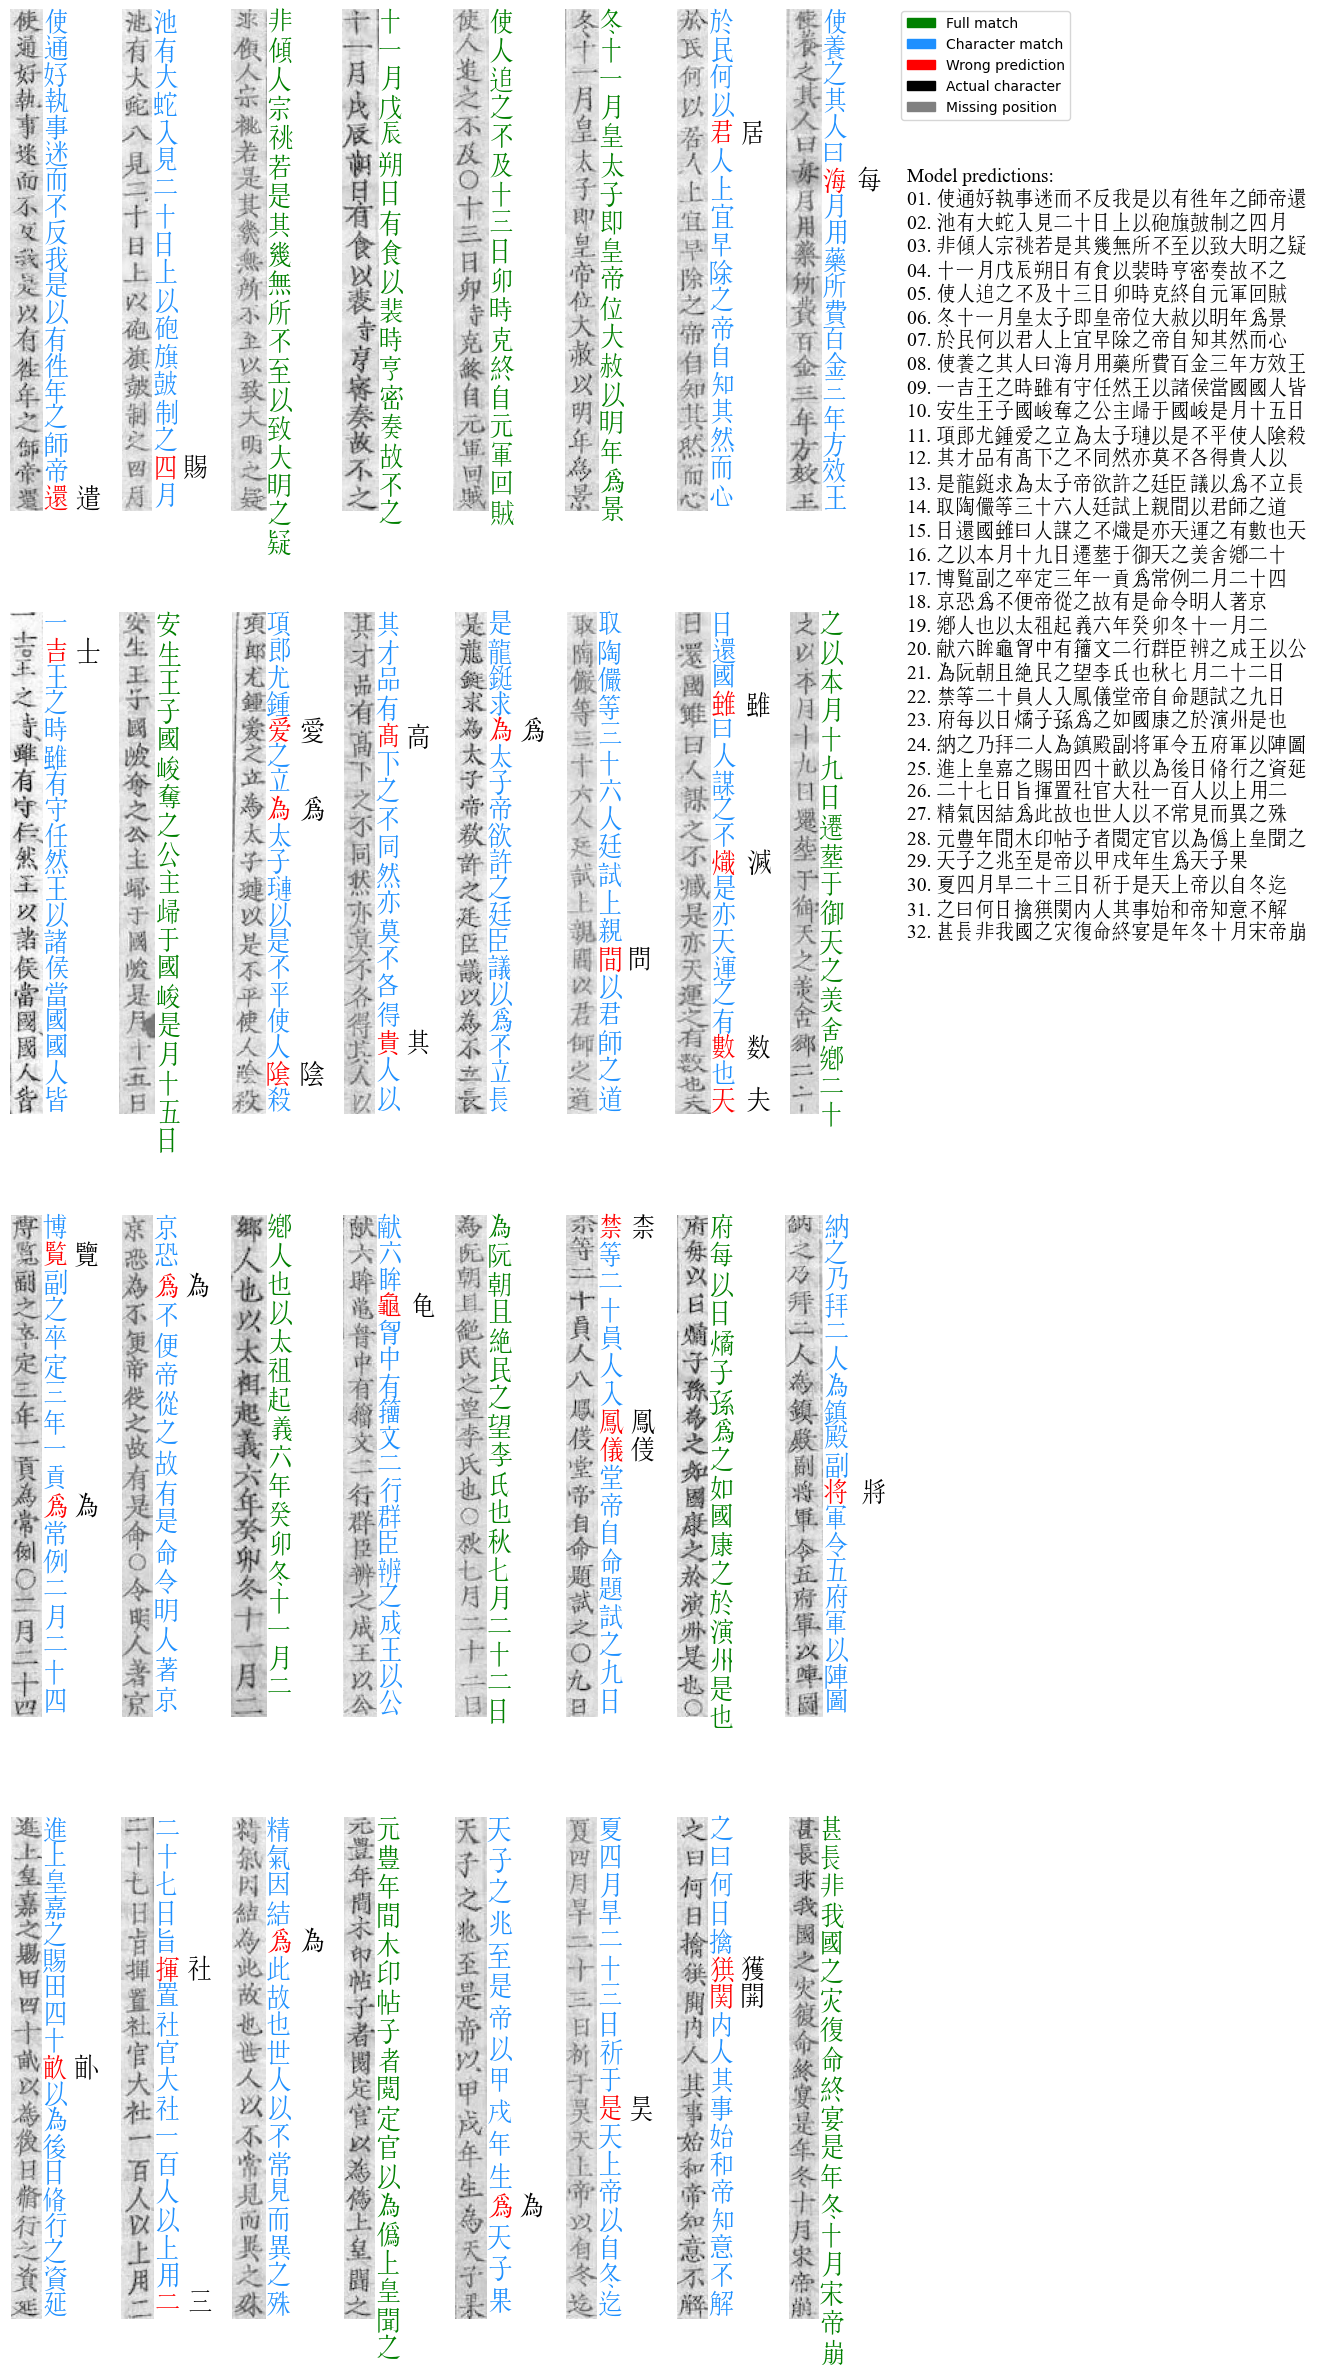

In [13]:
valid_iter = iter(valid_loader)
batch_images, batch_tokens = next(valid_iter)
idxs_in_batch = valid_idxs[:BATCH_SIZE]
labels = data_handler.tokens2texts(batch_tokens)

with torch.no_grad():
    pred_tokens = reset_model(batch_images.to(device)).argmax(dim=-1)
pred_labels = data_handler.tokens2texts(pred_tokens, use_ctc_decode=True)

visualize_images_labels(
    img_paths = dataset.img_paths[idxs_in_batch], 
    labels = labels, 
    pred_labels = pred_labels,
    figsize = (11.6, 30),
    subplot_size = (4, 8),
    legend_loc = (3.8, 4.38),
    annotate_loc = (4, 2.75),
    font_path = FONT_PATH, 
)
print(
    f'Batch 01:\n'
    f'- True: {dict(enumerate(labels, start=1))}\n'
    f'- Pred: {dict(enumerate(pred_labels, start=1))}\n'
)

In [14]:
class Evaluator:
    def __init__(self, model, dataset_dir, transcripts_path):
        self.model = model
        self.dataset = DataImporter(dataset_dir, transcripts_path, min_length=1)
        self.loader = None

    def evaluate(self, data_handler, batch_size, drop_remainder=False):
        self.data_handler = data_handler
        idxs = list(range(self.dataset.size))
        self.loader = data_handler.prepare_pytorch_dataset(idxs, batch_size, drop_remainder=drop_remainder)
        
        self.model.eval()
        val_loss = 0.0
        val_seq_acc = SequenceAccuracy(data_handler)
        val_char_acc = CharacterAccuracy(data_handler)
        val_lev = LevenshteinDistance(data_handler, normalize=True)

        with torch.no_grad():
            for images, labels in self.loader:
                images = images.to(device)
                preds = self.model(images)
                log_probs = preds.permute(1, 0, 2)
                input_lengths = torch.full(size=(images.size(0),), fill_value=preds.size(1), dtype=torch.long)
                targets_1d = torch.cat([
                    label[label != 0]
                    for label in labels
                ])
                
                target_lengths = torch.tensor(
                    [len(label[label != 0]) for label in labels],
                    dtype=torch.long,
                    device=images.device
                )
                
                loss = ctc_loss_fn(
                    log_probs,
                    targets_1d,
                    input_lengths,
                    target_lengths
                )

                val_loss += loss.item() * images.size(0)

                pred_texts = data_handler.decode_predictions(preds)
                true_texts = data_handler.tokens2texts(labels, use_ctc_decode=False)

                val_seq_acc.update(true_texts, pred_texts)
                val_char_acc.update(true_texts, pred_texts)
                val_lev.update(true_texts, pred_texts)

        val_loss /= len(self.loader.dataset)
        return {
            'loss': val_loss,
            'seq_acc': val_seq_acc.compute(),
            'char_acc': val_char_acc.compute(),
            'levenshtein_distance': val_lev.compute()
        }


GT10_TRANSCRIPTS_PATH = f'{DATASET_DIR}/Validate_gt10.txt'
LTE10_TRANSCRIPTS_PATH = f'{DATASET_DIR}/Validate_lte10.txt'

gt10_evaluator = Evaluator(reset_model, DATASET_DIR, GT10_TRANSCRIPTS_PATH)
lte10_evaluator = Evaluator(reset_model, DATASET_DIR, LTE10_TRANSCRIPTS_PATH)
df = pd.DataFrame([
    gt10_evaluator.evaluate(data_handler, BATCH_SIZE),
    lte10_evaluator.evaluate(data_handler, BATCH_SIZE),
])
df.index = ['Length > 10', 'Length ≤ 10']
df

,loss,seq_acc,char_acc,levenshtein_distance
Length > 10,0.046877,0.854626,0.983934,0.013534
Length ≤ 10,0.047269,0.855299,0.983919,0.013560


In [15]:
!pip install onnx2tf
import os
import torch
import onnx2tf
import tensorflow as tf

# ==========================================
# 1. LOAD YOUR TRAINED PYTORCH CRNN MODEL
# ==========================================
device = torch.device('cpu')

reset_model = build_crnn(VOCAB_SIZE)
reset_model.load_state_dict(torch.load(f'{APPROACH_NAME}.pt', map_location=device))
reset_model.eval()

# Input shape: (Batch=1, Channels=3, Height, Width)
dummy_input = torch.randn(1, 3, HEIGHT, WIDTH, device=device)
onnx_file = "crnn_model.onnx"

# ==========================================
# 2. EXPORT PYTORCH TO ONNX
# ==========================================
torch.onnx.export(
    reset_model,
    dummy_input,
    onnx_file,
    export_params=True,
    opset_version=14,
    do_constant_folding=True,
    input_names=['image'],
    output_names=['output'],
    dynamo=False
)
print(f"✅ Step 1/3: Exported ONNX model to {onnx_file}")

# ==========================================
# 3. CONVERT ONNX TO UNQUANTIZED (FLOAT32) TFLITE
# ==========================================
onnx2tf.convert(
    input_onnx_file_path=onnx_file,
    output_folder_path="crnn_tf_float32",
    copy_onnx_input_output_names_to_tflite=True,
    output_integer_quantized_tflite=False,
    enable_rnn_unroll=True,
    flatbuffer_direct_output_saved_model=True
)

# Locate and move the float32 TFLite output file
tflite_src = None
for root, _, files in os.walk("crnn_tf_float32"):
    for file in files:
        if file.endswith("_float32.tflite") or file == "model.tflite":
            tflite_src = os.path.join(root, file)
            break

if tflite_src and os.path.exists(tflite_src):
    os.replace(tflite_src, "crnn_float32.tflite")
    print("✅ Step 2/3: Exported Unquantized TFLite -> crnn_float32.tflite")

# ==========================================
# 4. CONVERT TO INT8 QUANTIZED TFLITE
# ==========================================
converter = tf.lite.TFLiteConverter.from_saved_model("crnn_tf_float32")

# Single-threaded calibration loader (num_workers=0 avoids process crashing)
calib_loader = data_handler.prepare_pytorch_dataset(
    train_idxs[:100],  # Use 100 samples for calibration
    batch_size=1,
    shuffle=False
)

def representative_dataset():
    for images, _ in calib_loader:
        # Convert PyTorch NCHW tensor -> TensorFlow NHWC format
        tf_img = images.numpy().transpose(0, 2, 3, 1)
        yield [tf_img.astype('float32')]

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

tflite_int8_model = converter.convert()

with open("crnn_int8.tflite", "wb") as f:
    f.write(tflite_int8_model)

print("✅ Step 3/3: Exported INT8 Quantized TFLite -> crnn_int8.tflite")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.5/223.5 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.

/tmp/ipykernel_24/3071898861.py:23: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset9.py:4553: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with GRU can cause an error when running the ONNX model with a different batch size. Make sure to save the model with a batch size of 1, or define the initial states (h0/c0) as inputs of the model. 
  return _generic_rnn(


✅ Step 1/3: Exported ONNX model to crnn_model.onnx

Model optimizing started ============================================================
Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃            ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Add        │ 9              │ 9                │
│ Concat     │ 2              │ 0                │
│ Constant   │ 63             │ 53               │
│ Conv       │ 21             │ 21               │
│ Expand     │ 2              │ 0                │
│ GRU        │ 2              │ 2                │
│ Gather     │ 2              │ 0                │
│ LogSoftmax │ 1              │ 1                │
│ MatMul     │ 1              │ 1                │
│ MaxPool    │ 3              │ 3                │
│ Relu       │ 18             │ 18               │
│ Reshape    │ 2              │ 2                │
│ Shape      │ 2              │ 0                │

flatbuffer_direct lowering:   0%|          | 0/62 [00:00<?, ?it/s]

flatbuffer_direct post-lowering:   0%|          | 0/6 [00:00<?, ?it/s]

...

flatbuffer_direct write timing: stage=float32 mode=builder_direct total=1.268s serialize=1.205s (sanitize=0.007s build=0.498s pack=0.635s output=0.066s) write=0.047s size=79.00MB


I0000 00:00:1786573299.827753      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8548 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786573299.830081      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


flatbuffer_direct write timing: stage=float16 mode=builder_direct total=0.509s serialize=0.479s (sanitize=0.007s build=0.045s pack=0.419s output=0.008s) write=0.024s size=39.89MB
Float32 tflite output complete! (crnn_tf_float32/crnn_model_float32.tflite)
Float16 tflite output complete! (crnn_tf_float32/crnn_model_float16.tflite)
SavedModel output complete! (crnn_tf_float32)
Tensor correspondence report output complete! (crnn_tf_float32/crnn_model_tensor_correspondence_report.json)
Input/Output tensor names are directly written from ONNX graph in flatbuffer_direct backend.
✅ Step 2/3: Exported Unquantized TFLite -> crnn_float32.tflite


W0000 00:00:1786573324.685243      24 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1786573324.685280      24 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1786573324.885894      24 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32


✅ Step 3/3: Exported INT8 Quantized TFLite -> crnn_int8.tflite
